In [ ]:
# Task 2: Customer Segmentation Analysis

## Project Objective
The objective of this project is to apply unsupervised machine learning (K-Means clustering) to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour. 
These behavioural segments enable targeted marketing campaigns, customer retention initiatives, and personalised communication.

## Analysis Workflow
1. Data Inspection & Cleaning: Inspect structure, remove missing customer IDs, filter out cancelled/negative transactions, and eliminate duplicate records.
2. Feature Engineering (RFM Analysis): Calculate Recency, Frequency, Monetary value (Customer Lifetime Value),and Average Purchase Value.
3. Data Preprocessing: Standardize features using `StandardScaler`.
4. K-Means Clustering: Use the Elbow Method to find the optimal $K$, fit the model, and assign cluster labels.
5. Visualization: Generate the Elbow curve, 2D scatter plots of feature pairs, and a customer distribution bar chart.
6. Cluster Profiling & Marketing Insights: Summarise segment statistics and formulate data-driven business actions.

In [ ]:
### 1. Import Libraries
We import Python libraries for data manipulation (pandas, numpy), data visualization (matplotlib.pyplot, seaborn),
and unsupervised machine learning (sklearn.preprocessing.StandardScaler, sklearn.cluster.KMeans).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Set visualization aesthetics
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
### 2. Load Dataset
We load OnlineRetail.csv using Pandas.Because the original retail file contains special characters in product descriptions, 
we specify encoding='latin1'.

In [4]:
df = pd.read_csv('OnlineRetail.csv', encoding='latin1')
print(f"Dataset loaded successfully with {df.shape[0]:,} rows and {df.shape[1]} columns.")
df.head()

Dataset loaded successfully with 541,909 rows and 8 columns.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
### 3. Inspect Data Types and Non-Null Counts
# We inspect column types and null counts using .info() to identify columns requiring type conversion or missing value handling.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [ ]:
### 4. Missing Values Analysis
We calculate the exact number and percentage of missing values per column.
For customer segmentation, records missing CustomerID cannot be assigned to an individual profile.

In [7]:
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_summary[missing_summary['Missing Count'] > 0]

,Missing Count,Missing Percentage (%)
Description,1454,0.27
CustomerID,135080,24.93


In [ ]:
### 5. Duplicate Rows Analysis
We check for exact duplicate transaction entries that would artificially skew order counts.

In [8]:
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count:,}")

Total duplicate rows: 5,268


In [ ]:
### 6. Inspect Inconsistencies (Cancellations and Non-Positive Values)
In transactional data, negative quantities often correspond to returned items or order cancellations (frequently designated by an 'InvoiceNo' starting with 'C').
Non-positive unit prices represent adjustments, bad debts, or gifts. We quantify these before filtering.

In [9]:
cancelled_invoices = df['InvoiceNo'].astype(str).str.startswith('C').sum()
non_positive_qty = (df['Quantity'] <= 0).sum()
non_positive_price = (df['UnitPrice'] <= 0).sum()

print(f"Invoices marked as cancelled ('C'): {cancelled_invoices:,}")
print(f"Rows with Quantity <= 0: {non_positive_qty:,}")
print(f"Rows with UnitPrice <= 0: {non_positive_price:,}")

Invoices marked as cancelled ('C'): 9,288
Rows with Quantity <= 0: 10,624
Rows with UnitPrice <= 0: 2,517


In [12]:
### 7. Clean the Dataset
# We clean the data by:
1. Removing rows where CustomerID is missing.
2. Dropping duplicate rows.
3. Filtering for valid completed purchases (Quantity > 0 and UnitPrice > 0).
4. Converting CustomerID to integer and InvoiceDate to datetime.
5. Calculating transaction-level TotalSpend = Quantity * UnitPrice.

In [13]:
# Filter out missing CustomerIDs, duplicates, and non-positive transactions
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean = df_clean.drop_duplicates()
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)].copy()

# Fix types
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Create spend feature
df_clean['TotalSpend'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Unique customers remaining: {df_clean['CustomerID'].nunique():,}")

Cleaned dataset shape: (392692, 9)
Unique customers remaining: 4,338


In [15]:
### 8. Cleaned Transaction Summary Statistics
# We compute summary statistics for Quantity, UnitPrice, and TotalSpend to verify that values are valid and positive.
df_clean[['Quantity', 'UnitPrice', 'TotalSpend']].describe().round(2)

,Quantity,UnitPrice,TotalSpend
count,392692.00,392692.00,392692.00
mean,13.12,3.13,22.63
std,180.49,22.24,311.10
min,1.00,0.00,0.00
25%,2.00,1.25,4.95
50%,6.00,1.95,12.45
75%,12.00,3.75,19.80
max,80995.00,8142.75,168469.60


In [ ]:
### 9. Calculate Customer-Level Behavioural Metrics (RFM Analysis)
To segment customers, we aggregate transactions to the individual customer level:
- Recency: Days elapsed since the customer's last order relative to the snapshot reference date (max(InvoiceDate) + 1 day)[cite: 1].
- Frequency: Total unique purchase orders (InvoiceNo.nunique()) made by the customer[cite: 1].
- Monetary (CLV proxy): Total amount spent across all transactions[cite: 1].
- Average Purchase Value (AOV): Monetary / Frequency[cite: 1].

In [16]:
# Establish snapshot date 1 day after the latest transaction
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Aggregate per customer
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (snapshot_date - date.max()).days,
    'InvoiceNo': 'nunique',
    'TotalSpend': 'sum'
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Calculate Average Purchase Value
rfm['AvgPurchaseValue'] = (rfm['Monetary'] / rfm['Frequency']).round(2)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,AvgPurchaseValue
0,12346,326,1,77183.60,77183.60
1,12347,2,7,4310.00,615.71
2,12348,75,4,1797.24,449.31
3,12349,19,1,1757.55,1757.55
4,12350,310,1,334.40,334.40


In [ ]:
### 10. Customer Descriptive Statistics
We calculate summary statistics across all 4,338 customers for Recency, Frequency, Monetary value, 
and Average Purchase Value to understand overall distribution and skewness.

In [17]:
rfm[['Recency', 'Frequency', 'Monetary', 'AvgPurchaseValue']].describe().round(2)


,Recency,Frequency,Monetary,AvgPurchaseValue
count,4338.00,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69,417.65
std,100.01,7.70,8985.23,1796.51
min,1.00,1.00,3.75,3.45
25%,18.00,1.00,306.48,177.86
50%,51.00,2.00,668.57,291.94
75%,142.00,5.00,1660.60,428.28
max,374.00,209.00,280206.02,84236.25


In [ ]:
### 11. Feature Selection and Normalization (StandardScaler)
K-Means relies on Euclidean distance to calculate the proximity of data points to cluster centroids[cite: 1]. Because Monetary
spans tens of thousands of units while Frequency spans small integers, unscaled features would allow monetary values to overpower the distance metric. 

We select 3 key behavioural features—"Recency", "Frequency", and "Monetary"—and normalize them with
StandardScaler so each feature has a mean of 0 and variance of 1[cite: 1].

In [18]:
features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head().round(3)

,Recency,Frequency,Monetary
0,2.335,-0.425,8.363
1,-0.905,0.354,0.252
2,-0.175,-0.035,-0.028
3,-0.735,-0.425,-0.032
4,2.175,-0.425,-0.191


In [ ]:
### 12. Elbow Method to Determine K
We evaluate K-Means for cluster sizes $K = 1$ to $K = 10$ using inertia (Within-Cluster Sum of Squares)[cite: 1].
The optimal number of clusters is located at the "elbow" point, where the rate of inertia reduction begins to level off[cite: 1].

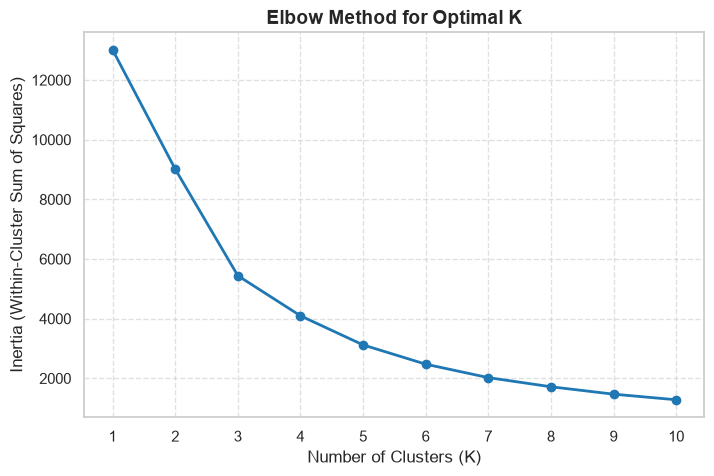

In [19]:
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', linewidth=2, color='#1f77b4')
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
### 13. Fit K-Means with Optimal K
Based on the Elbow plot, we select $K = 3$ as the optimal number of clusters.
We fit the final K-Means model and append the resulting cluster labels back to our customer RFM DataFrame.

In [20]:
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(X_scaled)

print("K-Means clustering complete. Assigned cluster distribution:")
print(rfm['Cluster'].value_counts().sort_index())

K-Means clustering complete. Assigned cluster distribution:
Cluster
0    1082
1    3230
2      26
Name: count, dtype: int64


In [ ]:
### 14.Profile Customer Clusters
We compute the mean values of Recency, Frequency, Monetary spend, and Average Purchase Value for each cluster, 
along with customer counts, to establish clear behavioural profiles[cite: 1]

In [21]:
cluster_profile = rfm.groupby('Cluster').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'AvgPurchaseValue': 'mean'
}).rename(columns={'CustomerID': 'CustomerCount'}).round(2)

# Calculate percentage share
cluster_profile['Percentage (%)'] = (cluster_profile['CustomerCount'] / len(rfm) * 100).round(2)

cluster_profile

,CustomerCount,Recency,Frequency,Monetary,AvgPurchaseValue,Percentage (%)
Cluster,,,,,,
0,1082,247.11,1.58,629.66,409.09,24.94
1,3230,41.45,4.67,1849.67,384.39,74.46
2,26,6.04,66.42,85826.08,4904.67,0.60


In [ ]:
### 15.Customer Count by Cluster
We visualize the size of each customer segment using a bar chart[cite: 2]

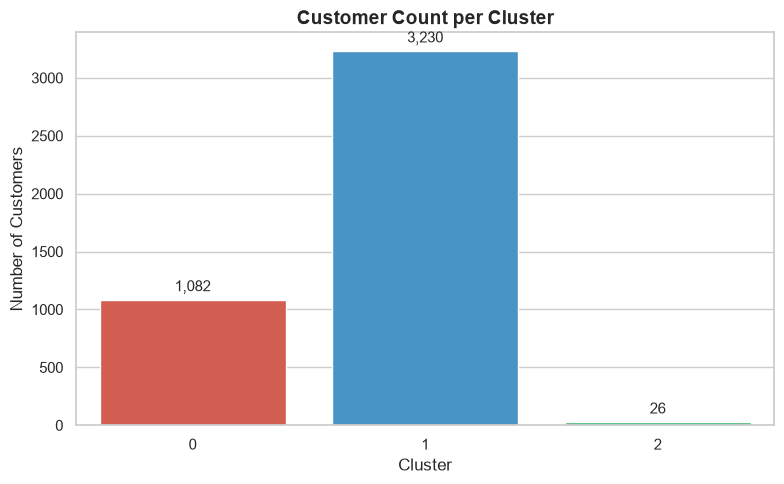

In [24]:
plt.figure(figsize=(8, 5))
palette = ['#e74c3c', '#3498db', '#2ecc71']
ax = sns.barplot(
    x=cluster_profile.index,
    y=cluster_profile['CustomerCount'],
    hue=cluster_profile.index,
    palette=palette,
    legend=False
)

plt.title('Customer Count per Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Annotate counts on top of bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, 
                xytext=(0, 4), textcoords='offset points')

plt.tight_layout()
plt.show()

In [ ]:
### 16. Scatter Plot: Recency vs Monetary Spend
We plotRecency against Monetary spend to evaluate customer spending patterns relative to how recently they transacted[cite: 1].

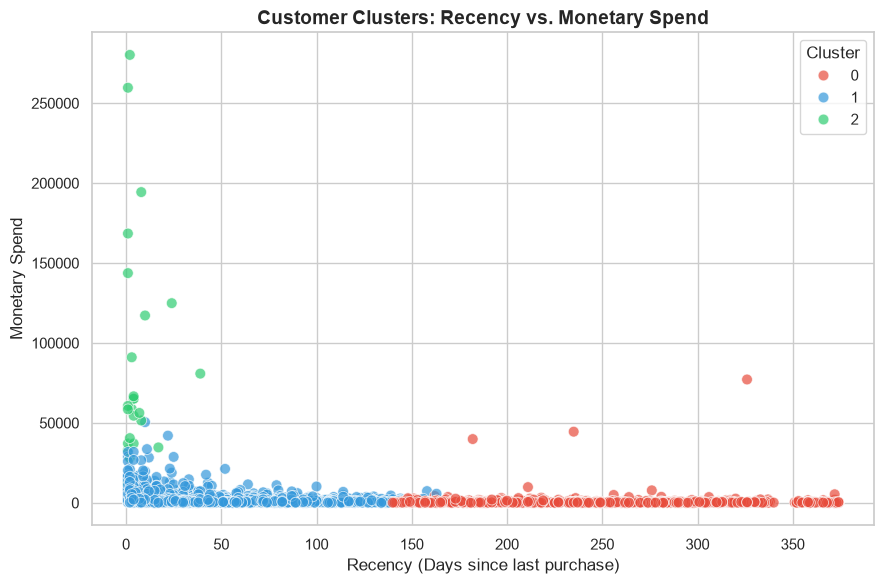

In [25]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette=['#e74c3c', '#3498db', '#2ecc71'],
    alpha=0.7,
    s=60
)

plt.title('Customer Clusters: Recency vs. Monetary Spend', fontsize=14, fontweight='bold')
plt.xlabel('Recency (Days since last purchase)', fontsize=12)
plt.ylabel('Monetary Spend', fontsize=12)
plt.legend(title='Cluster', loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
### 17. Scatter Plot: Frequency vs Monetary Spend
We plot Frequency against Monetary spend to observe the relationship between order volumes and total customer revenue[cite: 1].

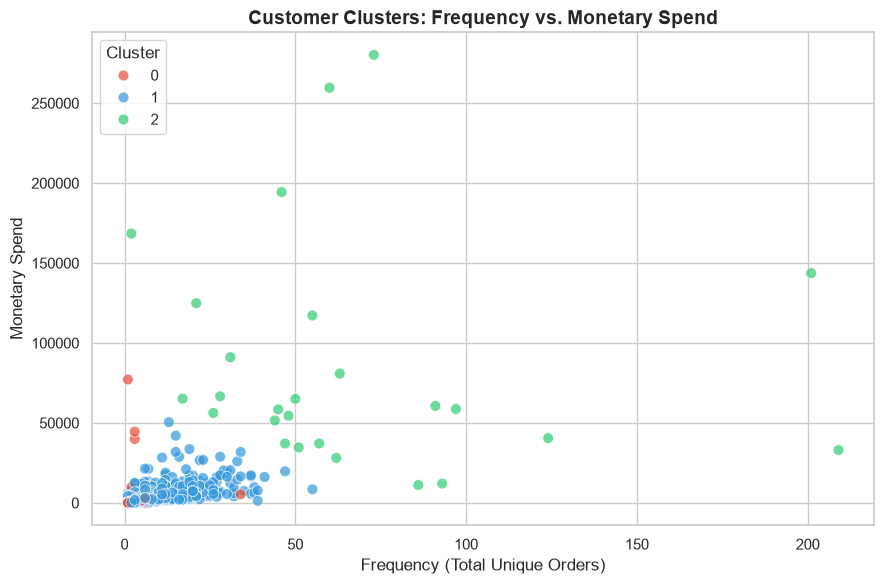

In [26]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette=['#e74c3c', '#3498db', '#2ecc71'],
    alpha=0.7,
    s=60
)

plt.title('Customer Clusters: Frequency vs. Monetary Spend', fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Total Unique Orders)', fontsize=12)
plt.ylabel('Monetary Spend', fontsize=12)
plt.legend(title='Cluster', loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
### 18.Cluster Interpretation and Marketing Strategy

Based on the empirical feature means from the clustering model, the segments are defined as follows:

## Cluster 0: At-Risk / Dormant Customers
* Observed Behaviour: Highest average recency (~247 days), lowest order frequency (~1.58 orders), and lowest total spend (~629.66).
* Business Interpretation: Customers who made one or two purchases long ago and have not returned for over 8 months.
* Actionable Strategy:
  * Implement automated "We miss you" re-engagement email workflows.
  * Offer targeted, limited-time win-back discounts or free delivery on their next order.
  * Solicit feedback surveys to uncover reasons for disengagement.

---

# Cluster 1: Active Regular Customers
* Observed Behaviour: Moderate-to-recent activity (~41.5 days recency), steady order frequency (~4.67 orders), and solid monetary spend (~1,849.67).
* Business Interpretation: The core revenue engine of the business, representing ~74% of the total customer base with consistent purchasing habits.
* Actionable Strategy:
  * Introduce a multi-tier loyalty/rewards programme to encourage frequent reorders.
  * Deploy cross-selling and product recommendation emails based on past categories purchased.
  * Send seasonal promotions and early-access announcements for new product launches.

---

## Cluster 2: VIP / High-Value Champions**
* Observed Behaviour: Extremely recent transactions (~6 days recency), high order frequency (~66 orders), and very high total spend (~85,826).
* Business Interpretation: A small group (~26 accounts, likely corporate or wholesale buyers) generating disproportionately high revenue.
* Actionable Strategy:
  * Provide dedicated account management and personalized concierge support.
  * Offer bulk-purchase volume incentives, customized invoices, or flexible payment terms.
  * Avoid excessive promotional discounting; instead, focus on priority fulfilment and premium service.

In [ ]:
## Final Project Summary

# 1. Key Findings
- Aggregating the transaction records yielded 4,338 unique, active customers.
- The business exhibits clear behavioural heterogeneity across Recency, Frequency, and Monetary spend.
- The Elbow Method confirmed that $K = 3$ produces well-differentiated, interpretable customer groupings.

### 2. Segment Overview
- Cluster 0 (At-Risk / Inactive): ~25% of customers with high days since last order (~247 days) and low spend.
- Cluster 1 (Active Core): ~74% of customers driving consistent volume with an average recency of ~41 days.
- Cluster 2 (High-Value VIPs): <1% of customers responsible for major revenue contributions with high frequency (~66 orders).

## 3. Business Value
The resulting segment labels allow the marketing team to transition from generic bulk marketing to tailored campaigns, optimizing return on marketing spend and improving customer retention.

# 4. Limitations
- Outlier Sensitivity: K-Means relies on spherical centroid calculation and is sensitive to extreme values in spend and order volume.
- Static Snapshot: RFM reflects a historical snapshot rather than real-time sequential purchasing trends over time.
- Product Semantics: Clustering considers transaction volume and spend, but does not capture product categories or customer demographic details.